Today’s task focused on **data preprocessing**, which is one of the most important steps in Machine Learning. The objective was to identify and handle missing values, correct datatype inconsistencies, and analyze the dataset for outliers before model building.

First, the dataset was checked for missing values to understand whether any columns contained incomplete information. Missing values are important because most Machine Learning algorithms cannot work properly with empty data. After identifying the missing values, the `TotalCharges` column was converted from object datatype into numerical datatype so that it could be used for analysis and modeling.

After datatype conversion, the dataset was re-evaluated to ensure that all missing values were properly handled. This step ensured that the dataset became clean and suitable for further Machine Learning operations.

Next, outlier analysis was performed on numerical features such as `tenure`, `MonthlyCharges`, and `TotalCharges`. Outliers are unusually high or low values that differ significantly from normal observations and can negatively affect model performance.

**Boxplots** were used to visually inspect the spread of data and detect possible outliers. The **IQR (Interquartile Range)** method was then applied to mathematically identify whether any values were outside the acceptable range.

After applying the IQR method, no significant outliers were detected in the dataset. This indicates that the dataset is already reasonably balanced and well-structured for Machine Learning modeling.

Overall, today’s work helped in understanding:

* **missing value detection**
* **datatype conversion**
* **data cleaning**
* **outlier detection techniques**
* importance of preprocessing in Machine Learning workflows

The dataset is now properly cleaned and prepared for the next stage of the project: **Feature Engineering and Model Preparation**.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('Telco_customer.csv')

In [2]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors='coerce')

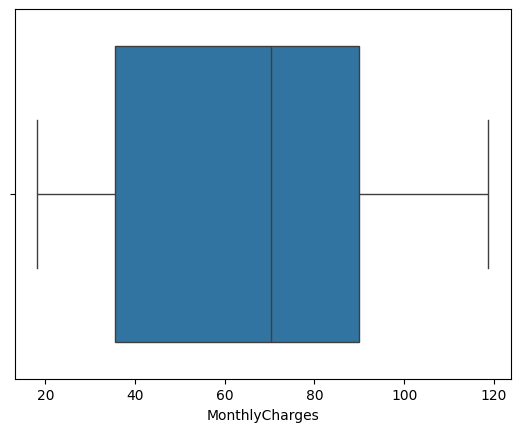

In [13]:
sns.boxplot(x=df['MonthlyCharges'])
plt.show()

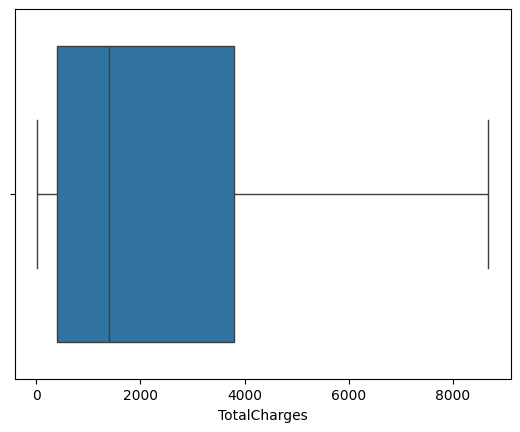

In [14]:
sns.boxplot(x=df['TotalCharges'])
plt.show()

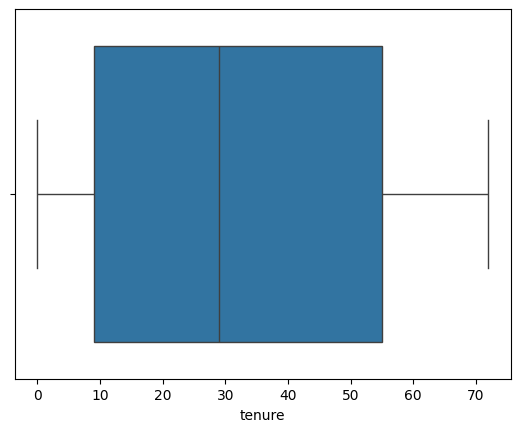

In [15]:
sns.boxplot(x=df['tenure'])
plt.show()

In [16]:
q1=df['MonthlyCharges'].quantile(0.25)
q3=df['MonthlyCharges'].quantile(0.75)
iqr=q3-q1
print(iqr)

54.349999999999994


In [17]:
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
print(lower_bound)
print(upper_bound)

-46.02499999999999
171.375


In [18]:
outliers=df[(df["MonthlyCharges"]<lower_bound) |(df["MonthlyCharges"]>upper_bound)]
outliers

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
